In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split
from torch.backends import cudnn
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  
from traindataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path, transform
import torch._dynamo  
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.verbose = False              # ← ADD THIS LINE
import time
import random
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)


Using device: cuda
CUDA Available: True, Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
2.10.0+cu130
True


In [9]:
import shutil

def crop_and_save_signature(input_path, output_path):
    size = 64
    target_size=56
    img = Image.open(input_path).convert('L')  # grayscale
    arr = np.array(img)

    # Find non-white pixels (threshold 240 to handle noise)
    coords = np.where(arr < 240)
    if len(coords[0]) == 0:
        img.resize((size, size), Image.Resampling.LANCZOS).save(output_path)
        return

    y0, y1 = coords[0].min(), coords[0].max() + 1
    x0, x1 = coords[1].min(), coords[1].max() + 1

    # Add 10% padding (prevents cutting edges)
    h, w = y1 - y0, x1 - x0
    pad_y = int(h * 0.1)
    pad_x = int(w * 0.1)

    y0 = max(0, y0 - pad_y)
    y1 = min(arr.shape[0], y1 + pad_y)
    x0 = max(0, x0 - pad_x)
    x1 = min(arr.shape[1], x1 + pad_x)

    cropped = img.crop((x0, y0, x1, y1))
    # Resize to 64x64 (keeps aspect ratio with white padding if needed)
    bg = Image.new('L', (size, size), 255)
    
    # Resize cropped signature to exactly target_size × target_size (preserving aspect ratio)
    cropped = cropped.resize((target_size, target_size), Image.Resampling.LANCZOS)
    
    # Center it
    x = (size - target_size) // 2
    y = (size - target_size) // 2
    bg.paste(cropped, (x, y))

    bg.save(output_path, "PNG", optimize=True)

# Run on your dataset
def pngfy(directories):
    
    for input_dir, output_dir in directories:
        
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir)   # ← nukes everything
            print(f"Deleted old folder: {output_dir}" )
        os.makedirs(output_dir, exist_ok=True)
        
        for file in os.listdir(input_dir):
                if file.endswith(('.PNG')):
                    crop_and_save_signature(os.path.join(input_dir, file),
                                        os.path.join(output_dir, file.split('.')[0] + ".PNG"))
                if file.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    crop_and_save_signature(os.path.join(input_dir, file),
                                        os.path.join(output_dir, file.split('.')[0] + ".png"))
    
    print("All datasets processed perfectly!")

print("All the datasets are processed perfectly!")

All the datasets are processed perfectly!


In [10]:
extract_path_initial =[
    ("./content/Reference(646)","./content/PNG/Reference(646)"),
    ('./content/Questioned(1287)','./content/PNG/Questioned(1287)')
]
directories = [
        ('./content/Offline Genuine','./content/PNG/Offline Genuine'),
        ('./content/Offline Forgeries','./content/PNG/Offline Forgeries')
    ]
for reference_extract_path_initial,reference_out_path_initial in extract_path_initial:
    for author_id in os.listdir(reference_extract_path_initial):
        ref_dir = os.path.join(reference_extract_path_initial,author_id)
        ref_out_dir = os.path.join(reference_out_path_initial,author_id)
        directories.append( (ref_dir, ref_out_dir) )
print(directories)

pngfy(directories)


[('./content/Offline Genuine', './content/PNG/Offline Genuine'), ('./content/Offline Forgeries', './content/PNG/Offline Forgeries'), ('./content/Reference(646)\\013', './content/PNG/Reference(646)\\013'), ('./content/Reference(646)\\017', './content/PNG/Reference(646)\\017'), ('./content/Reference(646)\\018', './content/PNG/Reference(646)\\018'), ('./content/Reference(646)\\019', './content/PNG/Reference(646)\\019'), ('./content/Reference(646)\\020', './content/PNG/Reference(646)\\020'), ('./content/Reference(646)\\021', './content/PNG/Reference(646)\\021'), ('./content/Reference(646)\\022', './content/PNG/Reference(646)\\022'), ('./content/Reference(646)\\023', './content/PNG/Reference(646)\\023'), ('./content/Reference(646)\\024', './content/PNG/Reference(646)\\024'), ('./content/Reference(646)\\025', './content/PNG/Reference(646)\\025'), ('./content/Reference(646)\\026', './content/PNG/Reference(646)\\026'), ('./content/Reference(646)\\027', './content/PNG/Reference(646)\\027'), ('.

In [2]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


In [4]:
torch.backends.cudnn.benchmark = True          # Huge speedup on fixed input size (256×256)
torch.backends.cuda.matmul.allow_tf32 = True   # +15–20% speed on Ampere/Ada (4060)
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')     # Use TensorFloat-32 where possible
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   

# DATA

In [5]:
dataset = SignatureVerificationDataset(
    genuine_dir=genuine_extract_path,
    forgery_dir=forgery_extract_path,
    transform=transform
)

dataloader = DataLoader(
    dataset, 
    batch_size=128,           # or 192/256 now that you use 64×64 images
    shuffle=True,
    num_workers=6,            # ← magic number for almost all gaming laptops
    pin_memory=True,          # ← very important with GPU
    prefetch_factor=2,
    persistent_workers=True
                       )


Genuine authors: 10, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016'])
Forgery authors: 10, dict_keys(['014', '004', '015', '016', '002', '006', '012', '009', '001', '003'])
Author 001: 24 genuine signatures
Author 002: 24 genuine signatures
Author 003: 24 genuine signatures
Author 004: 24 genuine signatures
Author 006: 24 genuine signatures
Author 009: 24 genuine signatures
Author 012: 24 genuine signatures
Author 014: 24 genuine signatures
Author 015: 24 genuine signatures
Author 016: 23 genuine signatures
Author 014: 16 forged signatures
Author 004: 11 forged signatures
Author 015: 12 forged signatures
Author 016: 16 forged signatures
Author 002: 12 forged signatures
Author 006: 12 forged signatures
Author 012: 12 forged signatures
Author 009: 12 forged signatures
Author 001: 8 forged signatures
Author 003: 12 forged signatures
Training Total pairs: 5673, Total labels: 5673
Training Positive pairs (label=1): 2737
Training Negative pairs (label=0): 293

In [6]:
from testdataset import SignatureVerificationTestDataset, reference_extract_path, ques_extract_path

testdataset = SignatureVerificationTestDataset(
    reference_extract_path,
    ques_extract_path,
    transform=transform
)
test_size = int(0.8 * len(testdataset))
val_size = len(testdataset) - test_size

test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

val_loader = DataLoader(val_dataset,
                        batch_size=128,           # or 192/256 now that you use 64×64 images
                        shuffle=False,
                        num_workers=6,            # ← magic number for almost all gaming laptops
                        pin_memory=True,          # ← very important with GPU
                        prefetch_factor=2,
                        persistent_workers=True
                       )

testdataloader = DataLoader(
    test_dataset,
    batch_size=128,           # or 192/256 now that you use 64×64 images
    shuffle=False,
    num_workers=6,            # ← magic number for almost all gaming laptops
    pin_memory=True,          # ← very important with GPU
    prefetch_factor=2,
    persistent_workers=True
)

Training Total pairs: 15392, Total labels: 15392
Training Positive pairs (label=1): 7752
Training Negative pairs (label=0): 7640


In [7]:
class SiameseCNN(nn.Module):
    def __init__(self):
        super(SiameseCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 5, padding=2),    nn.BatchNorm2d(64),   nn.PReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 5, padding=2),  nn.BatchNorm2d(128),  nn.PReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))   # → (B, 256, 1, 1)
        )

        # === Classifier head (after GAP) ===
        self.classifier = nn.Sequential(
            nn.Linear(256, 1024),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512)
        )

    def forward_one(self, x):
        x = self.features(x)           # → (B, 256, 1, 1)
        x = torch.flatten(x, 1)        # → (B, 256)   ← THIS WAS MISSING!
        x = self.classifier(x)         # → (B, 512)
        x = F.normalize(x, p=2, dim=1)  # ← L2 NORM — ABSOLUTELY CRITICAL!
        return x

    # Siamese forward (two images)
    def forward(self, x1, x2):
        emb1 = self.forward_one(x1)
        emb2 = self.forward_one(x2)
        return emb1, emb2


In [8]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        # cosine_sim = nn.functional.cosine_similarity(emb1, emb2)
        # # cosine_sim=abs(cosine_sim)
        # loss = label * (1 - cosine_sim) + (1 - label) * torch.clamp(cosine_sim - self.margin, min=0)
        # return loss.mean()
    
        cos_sim = F.cosine_similarity(emb1, emb2)

        # Convert to cosine distance (0 = identical, 2 = opposite)
        dist = (1 - cos_sim)/2

        # Positive (genuine): want dist → 0
        pos = label * dist.pow(2)

        # Negative (forged): want dist > margin
        neg = (1 - label) * F.relu(self.margin - dist).pow(2)

        return (pos + neg).mean()

        # distance = F.pairwise_distance(emb1, emb2)           # Euclidean distance
        # loss = label * distance.pow(2) + \
        #        (1 - label) * F.relu(self.margin - distance).pow(2)
        # return loss.mean()


In [11]:
# Training with mixed precision
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
margin=0.8
lr=0.0001
threshold=0.03
model=SiameseCNN()
model = torch.compile(model, mode="reduce-overhead")   # or "default"
model = model.to(device)

criterion = ContrastiveLoss(margin=margin)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  # AdamW > Adam
scaler = GradScaler()
num_epochs = 25
epoch_losses = []
epoch_times = []


for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    start_time = time.time()                     # ← epoch start
    for img1, img2, labels in dataloader:
        img1, img2, labels = img1.to(device, non_blocking=True), img2.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)          # ← faster than zero_grad()
        
        with autocast('cuda', dtype=torch.bfloat16):   # bfloat16 = faster + same accuracy on 40-series
            emb1, emb2 = model(img1, img2)
            # labels[labels == 0] = -1
            loss = criterion(emb1, emb2, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                     # ← helps with gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent spikes
        scaler.step(optimizer)
        scaler.update()
        batch_losses.append(loss.item())
    
      # Timing
    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)
    avg_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(avg_loss)

    # Beautiful, correct, informative output
    print(f"Epoch {epoch:2d}/{num_epochs} | "
          f"Loss: {avg_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"Avg: {sum(epoch_times)/len(epoch_times):.1f}s | "
          f"Speed: {epoch_time/len(dataloader)*1000:.1f} ms/batch")

# Plot training loss curve
# plt.figure(figsize=(8, 6))
# plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', label=f"m={margin}, lr={lr}")
# plt.xlabel('Epoch')
# plt.ylabel('Contrastive Loss')
# plt.title(f'Loss Curve (margin={margin}, lr={lr})')
# plt.legend()
# plt.grid(True)
# plt.show()
# plt.savefig(f'second_saved_models/saved_models/LENET/loss_margin_LENET_256size{margin}_lr{lr}.png')


model_path = f"second_saved_models/savedmodels/dropoutCNN/siamese_margin{margin}_size64_dropout4_lr{lr}.pt"


torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")


Epoch  0/25 | Loss: 0.1263 | Time: 4.1s | Avg: 4.1s | Speed: 90.3 ms/batch
Epoch  1/25 | Loss: 0.0442 | Time: 3.7s | Avg: 3.9s | Speed: 83.3 ms/batch
Epoch  2/25 | Loss: 0.0058 | Time: 3.8s | Avg: 3.9s | Speed: 83.8 ms/batch
Epoch  3/25 | Loss: 0.0012 | Time: 3.7s | Avg: 3.8s | Speed: 83.2 ms/batch
Epoch  4/25 | Loss: 0.0006 | Time: 3.7s | Avg: 3.8s | Speed: 82.9 ms/batch
Epoch  5/25 | Loss: 0.0007 | Time: 3.7s | Avg: 3.8s | Speed: 83.1 ms/batch
Epoch  6/25 | Loss: 0.0020 | Time: 3.7s | Avg: 3.8s | Speed: 82.9 ms/batch
Epoch  7/25 | Loss: 0.0028 | Time: 3.8s | Avg: 3.8s | Speed: 83.4 ms/batch
Epoch  8/25 | Loss: 0.0017 | Time: 3.7s | Avg: 3.8s | Speed: 83.3 ms/batch
Epoch  9/25 | Loss: 0.0018 | Time: 3.8s | Avg: 3.8s | Speed: 84.4 ms/batch
Epoch 10/25 | Loss: 0.0004 | Time: 3.8s | Avg: 3.8s | Speed: 84.0 ms/batch
Epoch 11/25 | Loss: 0.0006 | Time: 3.7s | Avg: 3.8s | Speed: 82.6 ms/batch
Epoch 12/25 | Loss: 0.0006 | Time: 3.8s | Avg: 3.8s | Speed: 84.6 ms/batch
Epoch 13/25 | Loss: 0.001

Accuracy:  0.5742
Precision: 0.5655
Recall:    0.6516
F1-score:  0.6055
AUC:       0.6457


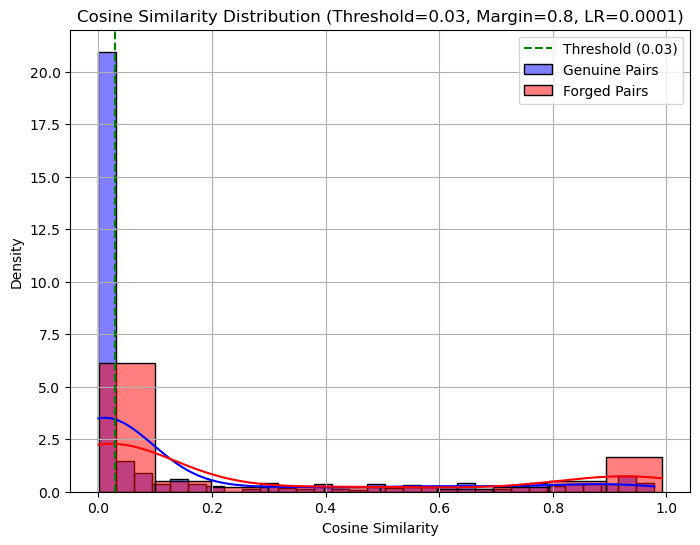

Threshold: 0.03, Accuracy: 0.0000


In [12]:
model.load_state_dict(torch.load(model_path, map_location=device))
# torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
model.eval()
correct = 0
total = 0
cosine_sim_all = []
labels_all = []

with torch.no_grad():
    for img1, img2, labels in val_loader:
        img1 = img1.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        try:
            with autocast("cuda", dtype=torch.bfloat16):
                emb1, emb2 = model(img1, img2)
                cosine_sim = F.cosine_similarity(emb1, emb2)
                # cosine_sim=F.normalize(cosine_sim)
                # cosine_sim=F.pairwise_distance(emb1, emb2)
                cosine_sim= (1-cosine_sim)/2
            cosine_sim_all.append(cosine_sim)
            labels_all.append(labels)
            # predictions = (cosine_sim < threshold).float()
            # correct += (predictions == labels).sum().item()
            total += labels.size(0)
        except RuntimeError as e:
            print(f"Error in evaluation: {e}")
            if "out of memory" in str(e):
                torch.cuda.empty_cache()
                continue

cosine_sim_all = torch.cat(cosine_sim_all)
labels_all = torch.cat(labels_all)
y_true = labels_all.cpu().numpy()
y_pred = (cosine_sim_all.cpu().numpy() < threshold).astype(int)

print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_true, 1 - cosine_sim_all.cpu().numpy()):.4f}")

# Histogram
indices = np.random.permutation(total)[:1000]
cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
labels_np = labels_all[indices].cpu().numpy()
cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

plt.figure(figsize=(8, 6))
sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
plt.legend()
plt.grid(True)
# plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
plt.show()  # Display the plot
plt.close()


In [ ]:
# # Load the model
# model = SiameseCNN().to(device)
# try:
#     model.load_state_dict(torch.load(PATH, map_location=device))
# except RuntimeError as e:
#     print(f"Error loading model: {e}")


In [ ]:
genuine_count = 0
forged_count = 0
total_samples = 0
for img1, img2, labels in dataloader:
    genuine_count += (labels == 1).sum().item()
    forged_count += (labels == 0).sum().item()
    total_samples += labels.size(0)
print(f"Genuine: {genuine_count} ({genuine_count / total_samples * 100:.2f}%), Forged: {forged_count} ({forged_count / total_samples * 100:.2f}%)")

In [ ]:
def evaluate_accuracy(model, testdataloader, margin, lr, threshold=0.5, device="cuda"):
    torch.cuda.empty_cache()  # Clears GPU cache in PyTorch
    model.eval()
    correct = 0
    total = 0
    cosine_sim_all = []
    labels_all = []
    
    with torch.no_grad():
        for img1, img2, labels in testdataloader:
            img1 = img1.to(device, non_blocking=True)
            img2 = img2.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            try:
                with autocast():
                    emb1, emb2 = model(img1, img2)
                    emb1 = F.normalize(emb1, p=2, dim=1)
                    emb2 = F.normalize(emb2, p=2, dim=1)
                    cosine_sim = F.cosine_similarity(emb1, emb2)
                cosine_sim_all.append(cosine_sim)
                labels_all.append(labels)
                predictions = (cosine_sim > threshold).float()
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
            except RuntimeError as e:
                print(f"Error in evaluation: {e}")
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue

    cosine_sim_all = torch.cat(cosine_sim_all)
    labels_all = torch.cat(labels_all)

    # Histogram
    indices = np.random.permutation(total)[:1000]
    cosine_sim_np = cosine_sim_all[indices].cpu().numpy()
    labels_np = labels_all[indices].cpu().numpy()
    cosine_sim_genuine = cosine_sim_np[labels_np == 1].tolist()
    cosine_sim_forged = cosine_sim_np[labels_np == 0].tolist()

    plt.figure(figsize=(8, 6))
    sns.histplot(cosine_sim_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
    sns.histplot(cosine_sim_forged, color='red', label='Forged Pairs', kde=True, stat='density')
    plt.axvline(x=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.title(f'Cosine Similarity Distribution (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Confusion Matrix
    predictions = (cosine_sim_all > threshold).float()
    cm = confusion_matrix(labels_all.cpu(), predictions.cpu())
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
    plt.title(f'Confusion Matrix (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(f"saved_models/LENET/confusion_matrix_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels_all.cpu(), cosine_sim_all.cpu())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Threshold={threshold}, Margin={margin}, LR={lr})')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig(f"saved_models/LENET/roc_curve_threshold_{threshold}_{margin}_{lr}.png")
    plt.show()  # Display the plot
    plt.close()

    # Metrics
    accuracy = correct / total if total > 0 else 0.0
    precision, recall, f1, _ = precision_recall_fscore_support(labels_all.cpu(), predictions.cpu(), average='binary')
    print(f"Threshold: {threshold}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}")
    
    return accuracy

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseCNN().to(device)  # Initialize model outside the loop
thresholds = [0.93]

# Load and evaluate models
for filename in os.listdir('./saved_models/LENET/'):
    if filename.endswith('.pt'):
        PATH = os.path.join('./saved_models/LENET', filename)
        parts = filename.split('_')
        margin = parts[1]  # e.g., 'margin0.5'
        lr = parts[2].replace('.pt', '')  # e.g., 'lr0.001'
        print(f"Attempting to load model: {filename}")
        print(margin,lr)
        if(margin=='margin0.8size256' and lr=="lr0.005"):
            try:
                model.load_state_dict(torch.load(PATH, map_location=device))
                print(f"Successfully loaded model from {PATH}")
                for thresh in thresholds:
                    accuracy = evaluate_accuracy(model, testdataloader, margin, lr, threshold=thresh, device=device)
                    print(f"Model: {filename}, Threshold: {thresh}, Accuracy: {accuracy:.4f}")
            except Exception as e:
                print(f"Error loading model {filename}: {e}")